In [1]:
# import Providentia
import providentia as prv

In [2]:
# magic to make plots appear inline
%matplotlib inline

# Initialise object

In [3]:
provi = prv.Providentia('trainings/20260722_Kuwait_Training_Dust_Modelling/kuwait.conf')

In [4]:
provi.print_config()

[TRAINING]
network = nasa-aeronet/directsun_v3-lev15
species = od550aero
resolution = 3hourly
start_date = 20250101
end_date = 20250801
model = a00c_cirrus-regional-000
report_type = kuwait
report_summary = True
report_stations = False


# Run download mode

In [5]:
provi.download()

Starting Providentia download...

Starting TRAINING section download...



Which type of data do you want to download? Observational, modelled or both? ([both]/obs/mod):  

Model data was detected in the configuration file. Do you want to download the interpolated version? (Otherwise, the non-interpolated model data will be downloaded) ([y]/n):  n



Using 12 CPUs.



There are some files that were already downloaded in a previous download, do you want to overwrite them ([y]/n)?  n



----------------------------------------


Some models/observations were found but were not downloaded because the user chose not to overwrite or because 'dl_overwrite' is set to False.


# Run interpolation

In [6]:
provi.interpolate()

Starting Providentia interpolation...

Starting TRAINING section interpolation...

Variables used for the interpolation:

ghost_version: 1.5
start_date: 202501
end_date: 202508
models:
 - a00c_cirrus-regional-000
species: ['od550aero']
network: ['nasa-aeronet/directsun_v3-lev15']
resolution: ['3hourly']
model_resolution: []
forecast: []
interp_spinup_timesteps: 0
interp_model_downsampling: mean
interp_model_upsampling: fill
interp_n_neighbours: 4
interp_reverse_vertical_orientation: False
interp_chunk_size: 16
interp_job_array_limit: 100
mod_root: /home/avilanov/data/providentia/mod
ghost_root: /home/avilanov/data/providentia/obs/ghost
nonghost_root: /home/avilanov/data/providentia/obs/nonghost
mod_to_interp_root: /home/avilanov/data/providentia/mod_to_interp
interp_multiprocessing: True

MODEL: a00c_cirrus-regional-000

Found speci to process on mapping od550du
31 observation file(s) for nasa-aeronet/directsun_v3-lev15 and 3hourly resolution were found in /home/avilanov/data/provident

# Load data

In [7]:
provi.load()


Updating file tree /home/avilanov/software/providentia/settings/internal/ghost_filetree_1.5.json...
Updating file tree /home/avilanov/software/providentia/settings/internal/nonghost_filetree.json...
Reading data

OBSERVATIONS
 - nasa-aeronet/directsun_v3-lev15|od550aero
MODELS
 - a00c_cirrus-regional-000
Resetting data filters to when class was initialised, loading TRAINING subsection filters.
Filtering data


# Save data to netCDF

In [8]:
provi.save(format='nc')

Data saved to /home/avilanov/software/providentia/saved_data/PRV_20260709_1154.nc


# Get data in memory

In [9]:
# return data in memory (in Xarray format)
data = provi.data(format='xr')
data

<xarray.Dataset> Size: 3MB
Dimensions:                                                      (
                                                                  data_label: 2,
                                                                  station_nasa-aeronet_directsun_v3-lev15|od550aero: 174,
                                                                  time: 1696,
                                                                  month: 7)
Coordinates:
  * time                                                         (time) datetime64[ns] 14kB ...
Dimensions without coordinates: data_label,
                                station_nasa-aeronet_directsun_v3-lev15|od550aero,
                                month
Data variables:
    data_labels                                                  (data_label) <U24 192B ...
    nasa-aeronet_directsun_v3-lev15|od550aero_data               (data_label, station_nasa-aeronet_directsun_v3-lev15|od550aero, time) float32 2MB ...
    nasa-aeronet_directsun_v3-lev15|od550aero_station_reference  (station_nasa-aeronet_directsun_v3-lev15|od550aero, month) <U19 93kB ...
    nasa-aeronet_directsun_v3-lev15|od550aero_longitude          (station_nasa-aeronet_directsun_v3-lev15|od550aero, month) float64 10kB ...
    nasa-aeronet_directsun_v3-lev15|od550aero_latitude           (station_nasa-aeronet_directsun_v3-lev15|od550aero, month) float64 10kB ...
    nasa-aeronet_directsun_v3-lev15|od550aero_station_name       (station_nasa-aeronet_directsun_v3-lev15|od550aero, month) <U19 93kB ...
Attributes:
    title:        Saved data from Providentia
    institution:  Barcelona Supercomputing Center
    source:       Providentia

# Make plots

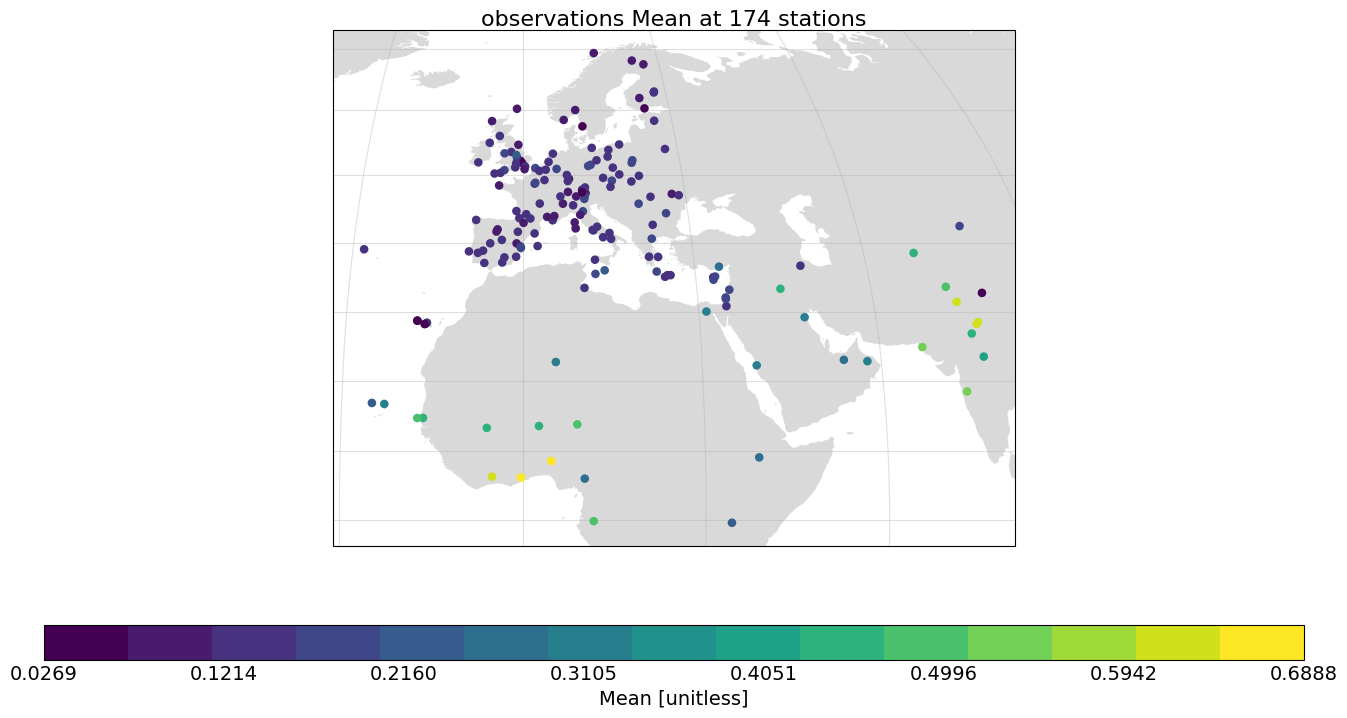

In [10]:
# make a map plot (mean of obs)
provi.plot('map-Mean', labela='observations')

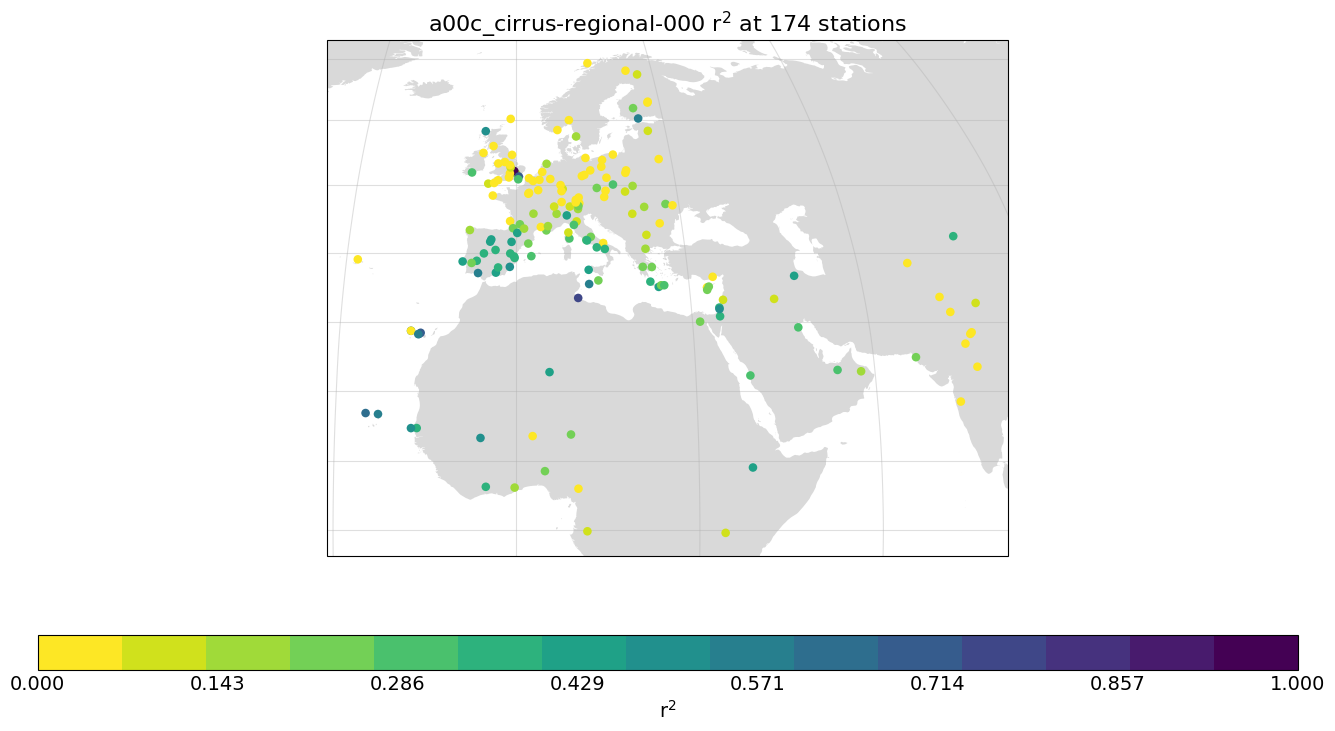

In [11]:
# make a map plot (r2 statistic)
provi.plot('map-r2', labela='observations', labelb='a00c_cirrus-regional-000')

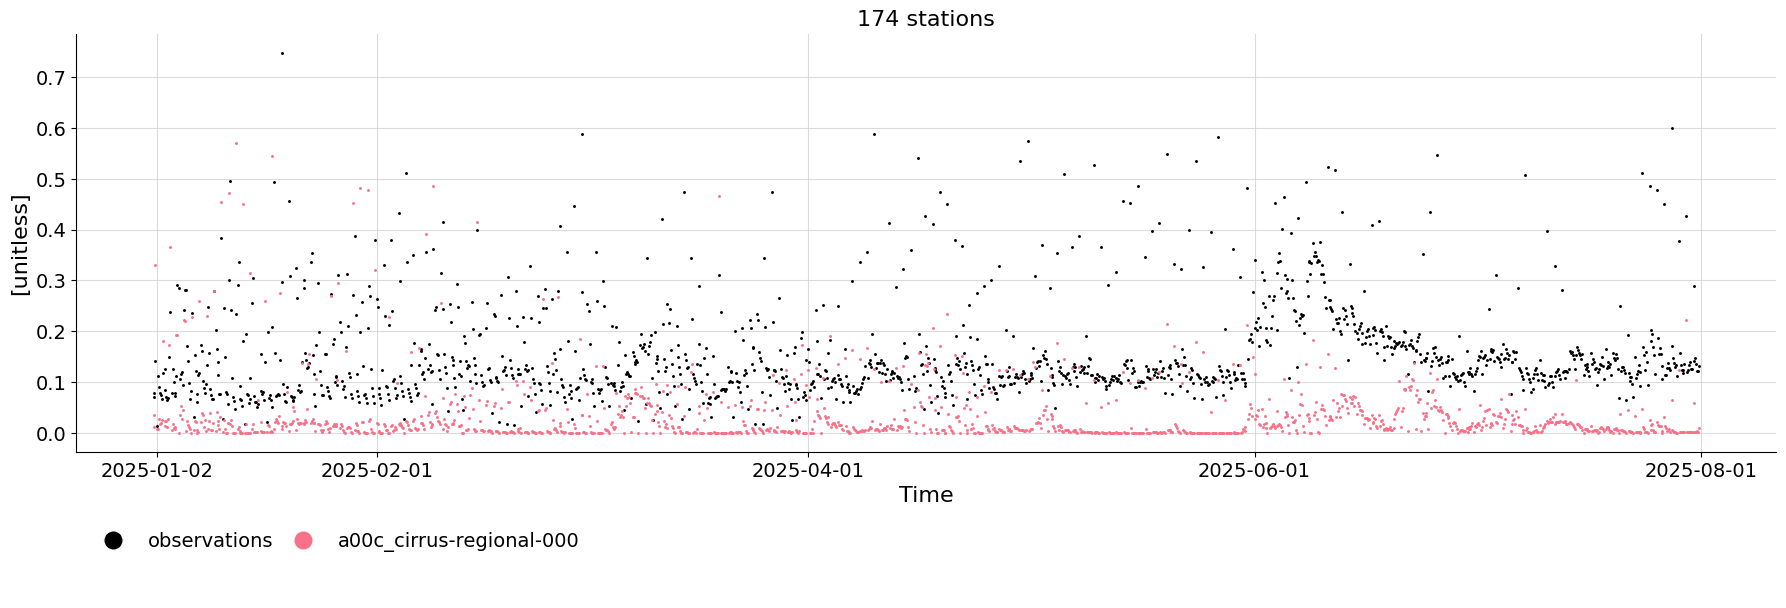

In [12]:
# make timeseries
provi.plot('timeseries')

Resetting data filters to when class was initialised, loading TRAINING subsection filters.
Filtering data
Resetting data filters to when class was initialised, loading TRAINING subsection filters.
Filtering data


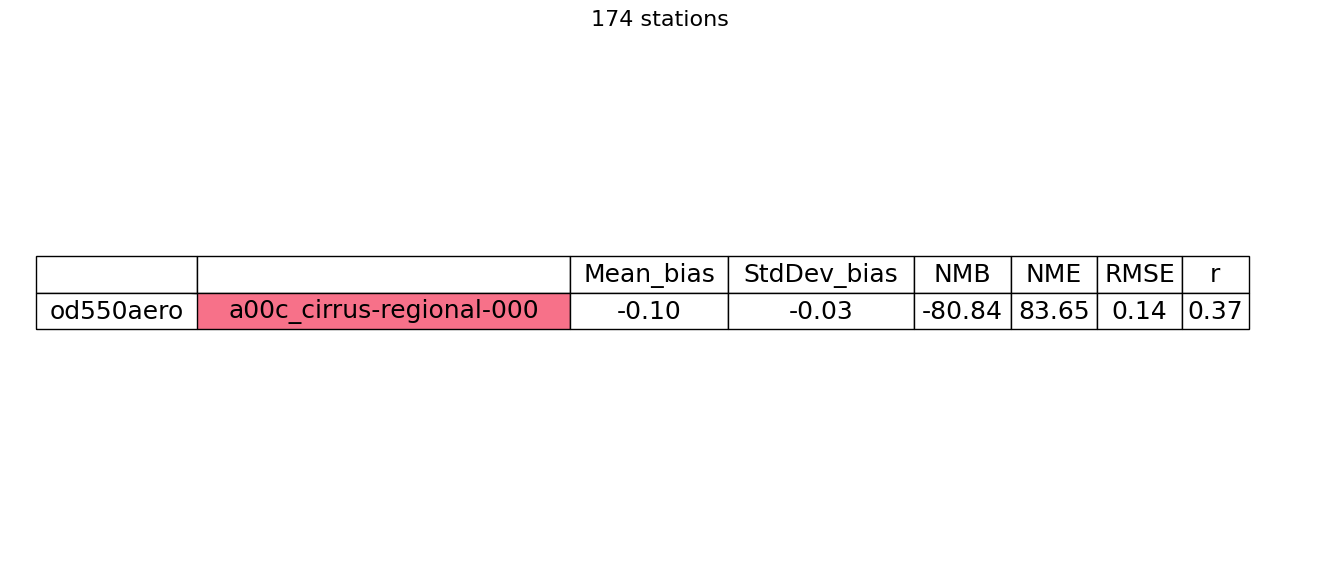

In [13]:
# make a statsummary plot
provi.plot('statsummary', multispecies=True, bias=True)

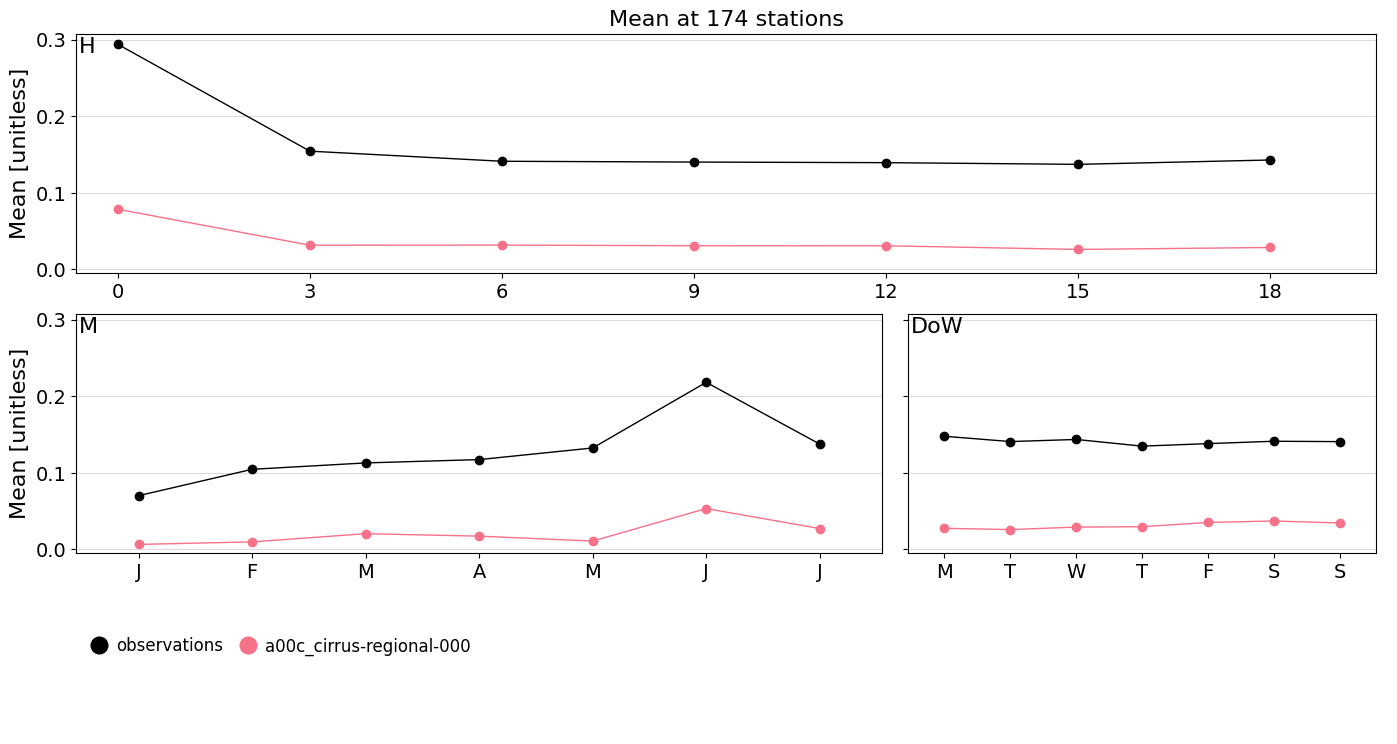

In [14]:
# make a periodic mean plot
provi.plot('periodic-Mean', threshold=True)

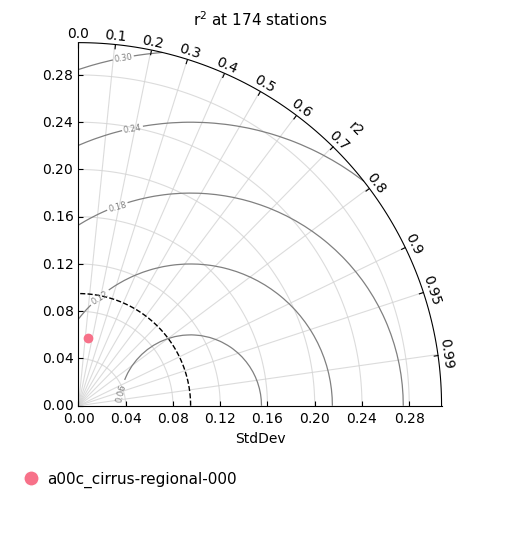

In [15]:
# make a Taylor diagram
provi.plot('taylor-r2')

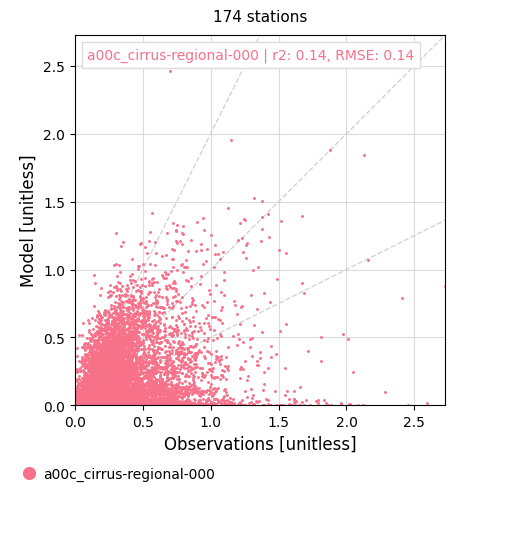

In [16]:
# make a scatter plot
provi.plot('scatter', annotate=True)

# Filter by station

In [17]:
# filter data by country metadata 
provi.reset()
provi.filter_station('Kuwait_University_2')
stations_data = provi.data(format='xr')
stations_data

Resetting all data filters.
Filtering data
Filtering data


<xarray.Dataset> Size: 29kB
Dimensions:                                                      (
                                                                  data_label: 2,
                                                                  station_nasa-aeronet_directsun_v3-lev15|od550aero: 1,
                                                                  time: 1696,
                                                                  month: 7)
Coordinates:
  * time                                                         (time) datetime64[ns] 14kB ...
Dimensions without coordinates: data_label,
                                station_nasa-aeronet_directsun_v3-lev15|od550aero,
                                month
Data variables:
    data_labels                                                  (data_label) <U24 192B ...
    nasa-aeronet_directsun_v3-lev15|od550aero_data               (data_label, station_nasa-aeronet_directsun_v3-lev15|od550aero, time) float32 14kB ...
    nasa-aeronet_directsun_v3-lev15|od550aero_station_reference  (station_nasa-aeronet_directsun_v3-lev15|od550aero, month) <U19 532B ...
    nasa-aeronet_directsun_v3-lev15|od550aero_longitude          (station_nasa-aeronet_directsun_v3-lev15|od550aero, month) float64 56B ...
    nasa-aeronet_directsun_v3-lev15|od550aero_latitude           (station_nasa-aeronet_directsun_v3-lev15|od550aero, month) float64 56B ...
    nasa-aeronet_directsun_v3-lev15|od550aero_station_name       (station_nasa-aeronet_directsun_v3-lev15|od550aero, month) <U19 532B ...
Attributes:
    title:        Saved data from Providentia
    institution:  Barcelona Supercomputing Center
    source:       Providentia

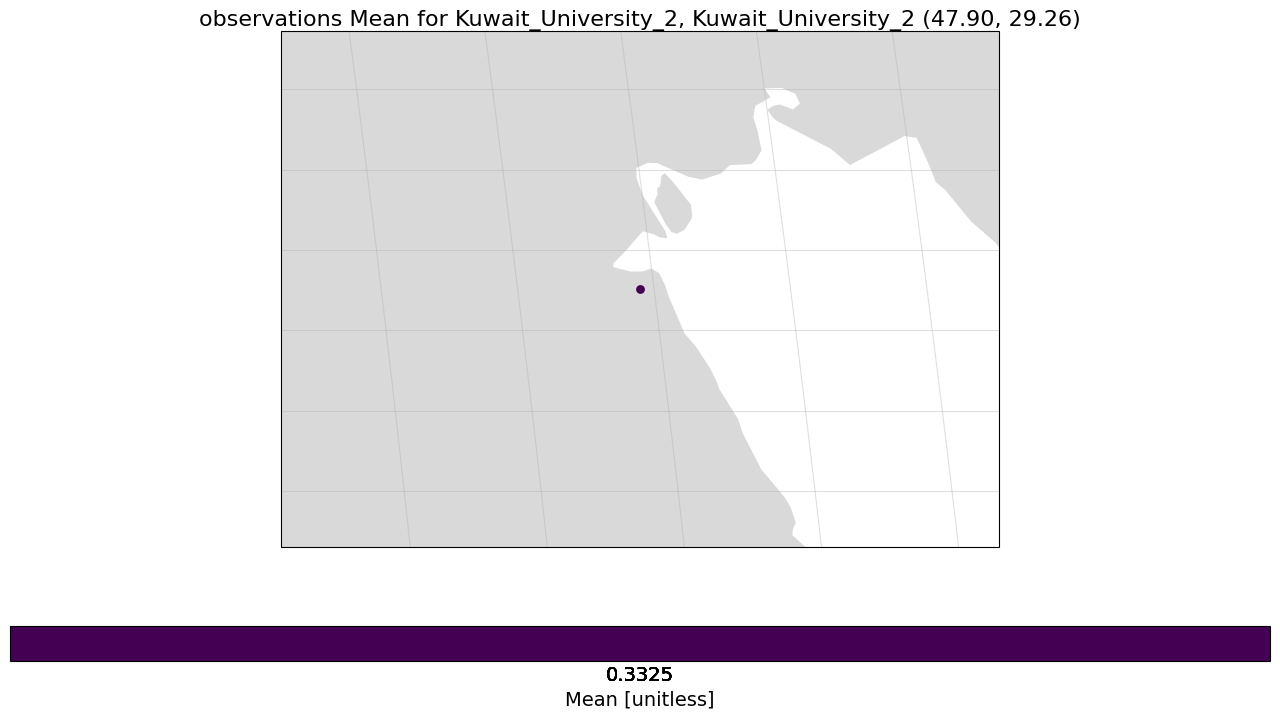

In [18]:
# make a map plot (mean of obs)
provi.plot('map-Mean', labela='observations')

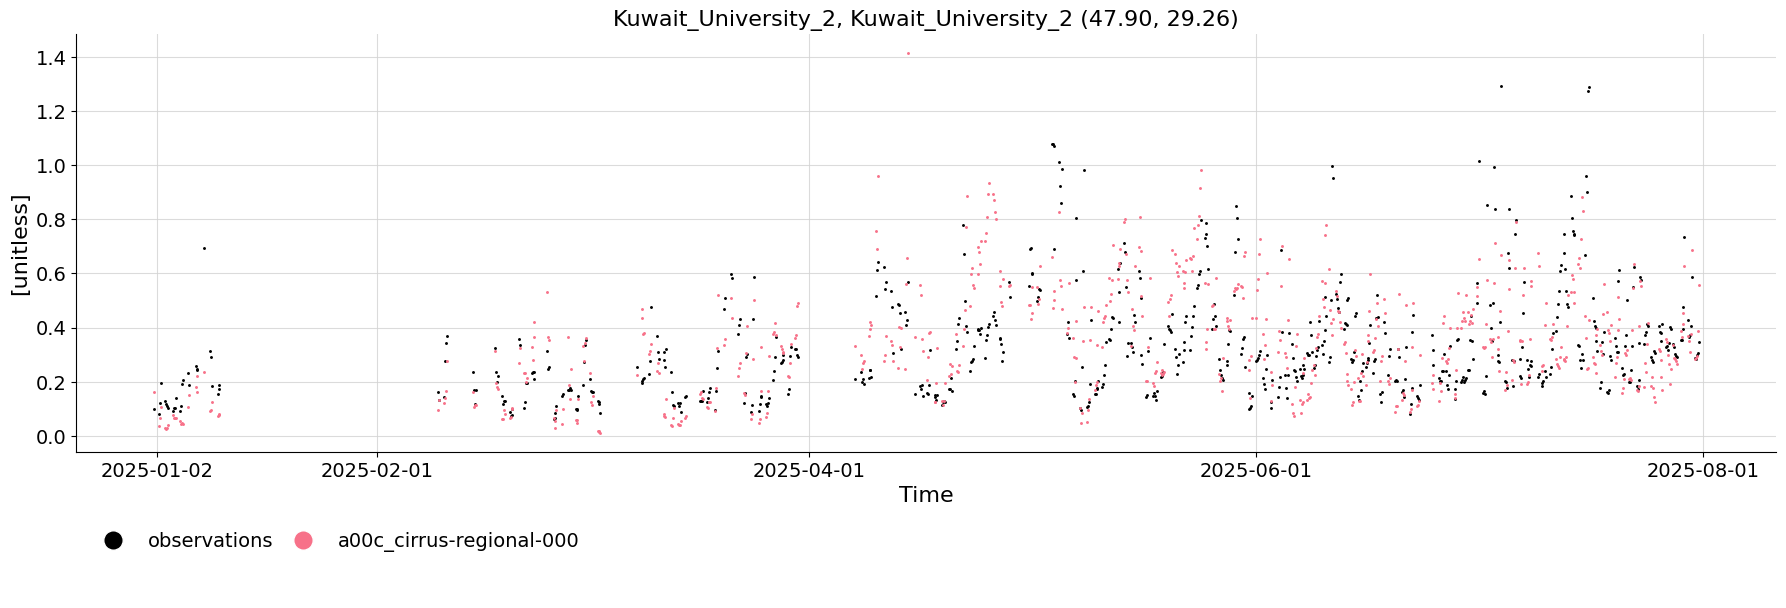

In [19]:
# make timeseries
provi.plot('timeseries')